In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [9]:
# health risk classification
df = pd.read_csv('https://raw.githubusercontent.com/atilsamancioglu/MachineLearningNotebooks/refs/heads/main/12-health_risk_classification.csv')

In [10]:
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [11]:
df.info() # scale edilmiş, temiz bir data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [12]:
df.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


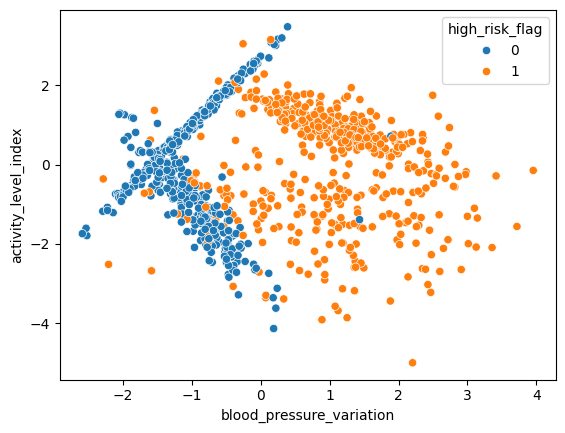

In [13]:
sns.scatterplot(x="blood_pressure_variation", y="activity_level_index", hue="high_risk_flag", data=df)
plt.show()

In [14]:
df.high_risk_flag.value_counts() # balance bir data

,count
high_risk_flag,
0,502
1,498


In [15]:
X = df.drop('high_risk_flag', axis=1)
y = df.high_risk_flag

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X ,y , test_size=0.25, random_state=15)

In [17]:
# knn de scale olayı önemlidir.

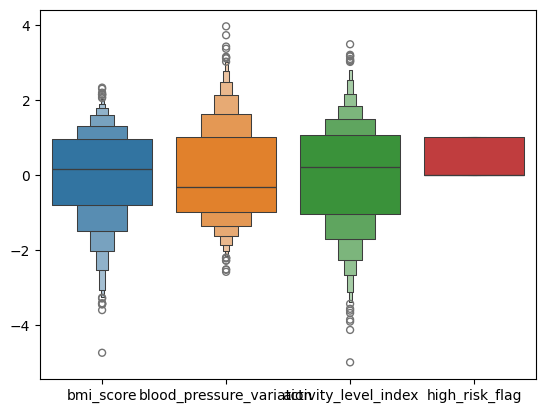

In [18]:
sns.boxenplot(df)
plt.show()
#zaten scale edilmiş bir data

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [20]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [22]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm="auto", weights="uniform") # n_neighbors bana bakacağımız komşu sayısını gösteriyor.

In [23]:
classifier.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [24]:
y_pred=classifier.predict(X_test_scaled)

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [26]:
print("Confusion Matrix: \n", confusion_matrix(y_pred, y_test))
print("Classification Report: \n", classification_report(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))

Confusion Matrix: 
 [[124  10]
 [  2 114]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250

accuracy score:  0.952


In [27]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm="kd_tree", weights="uniform")
classifier.fit(X_train_scaled, y_train)

KNeighborsClassifier(algorithm='kd_tree')

In [28]:
y_pred=classifier.predict(X_test_scaled)
print("Confusion Matrix: \n", confusion_matrix(y_pred, y_test))
print("Classification Report: \n", classification_report(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))

Confusion Matrix: 
 [[124  10]
 [  2 114]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250

accuracy score:  0.952


In [29]:
classifier = KNeighborsClassifier(n_neighbors=3, algorithm="kd_tree", weights="uniform")
classifier.fit(X_train_scaled, y_train)

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=3)

In [30]:
y_pred=classifier.predict(X_test_scaled)
print("Confusion Matrix: \n", confusion_matrix(y_pred, y_test))
print("Classification Report: \n", classification_report(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))

Confusion Matrix: 
 [[125   9]
 [  1 115]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.93      0.96       134
           1       0.93      0.99      0.96       116

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250

accuracy score:  0.96


In [31]:
classifier = KNeighborsClassifier(n_neighbors=350, algorithm="kd_tree", weights="uniform")
classifier.fit(X_train_scaled, y_train)

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=350)

In [32]:
y_pred=classifier.predict(X_test_scaled)
print("Confusion Matrix: \n", confusion_matrix(y_pred, y_test))
print("Classification Report: \n", classification_report(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))

# accuracy çok düşüyor 0.924

Confusion Matrix: 
 [[124  17]
 [  2 107]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.88      0.93       141
           1       0.86      0.98      0.92       109

    accuracy                           0.92       250
   macro avg       0.92      0.93      0.92       250
weighted avg       0.93      0.92      0.92       250

accuracy score:  0.924


In [33]:
################### data 02 ##############################

In [34]:
df_reg = pd.read_csv('https://raw.githubusercontent.com/atilsamancioglu/MachineLearningNotebooks/refs/heads/main/12-house_energy_regression.csv')

In [35]:
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [36]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [37]:
df_reg.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


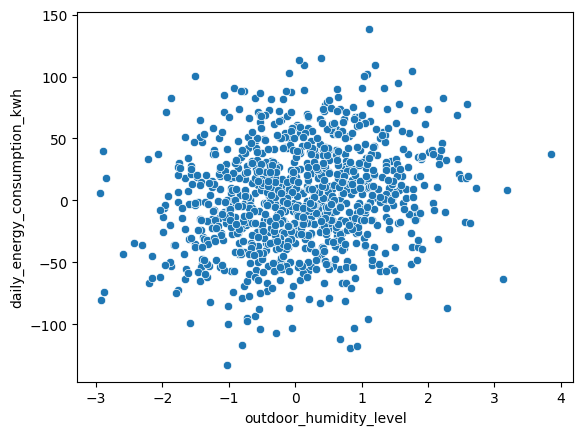

In [38]:
sns.scatterplot(x="outdoor_humidity_level", y="daily_energy_consumption_kwh", data=df_reg)
plt.show()

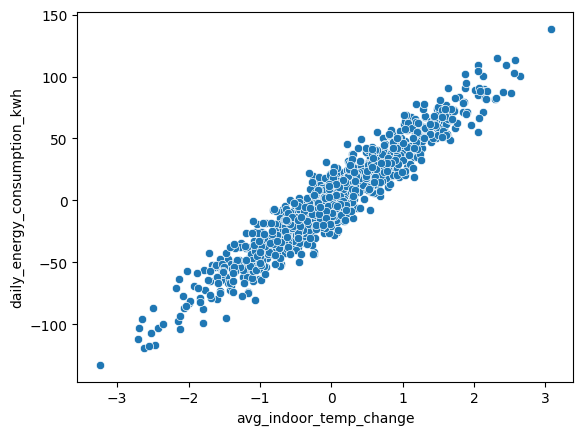

In [39]:
sns.scatterplot(x="avg_indoor_temp_change", y="daily_energy_consumption_kwh", data=df_reg)
plt.show()

In [43]:
df_reg.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


In [44]:
X = df_reg.drop('daily_energy_consumption_kwh', axis=1)
y = df_reg.daily_energy_consumption_kwh

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X ,y , test_size=0.3, random_state=15)

In [46]:
scaler = StandardScaler() # scale edilmiş bir data ma olsun.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
from sklearn.neighbors import KNeighborsRegressor

In [48]:
regressor = KNeighborsRegressor(n_neighbors=5, algorithm="auto")
regressor.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [54]:
y_pred = regressor.predict(X_test_scaled)

In [55]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [56]:
print("r2 score: ", r2_score(y_test, y_pred))
print("mean absolute error: ", mean_absolute_error(y_test, y_pred))
print("mean squared error: ", mean_squared_error(y_test, y_pred))

r2 score:  0.9152685146562609
mean absolute error:  9.42143518926242
mean squared error:  140.40201685069158


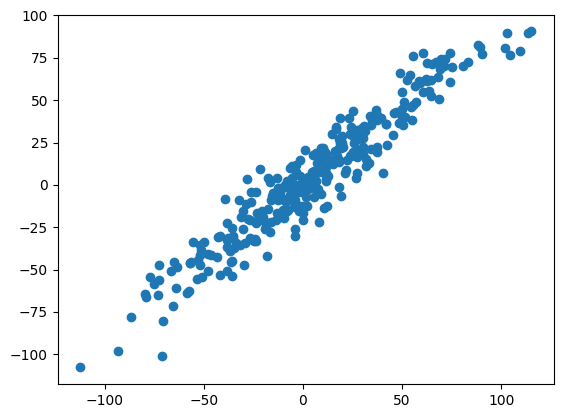

In [57]:
plt.scatter(y_test, y_pred)
plt.show()

r2 score:  0.9164863388635838
mean absolute error:  9.331428506491209
mean squared error:  138.3840541750219


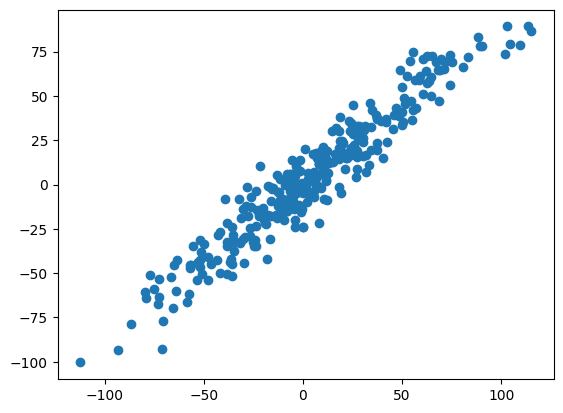

In [58]:
regressor = KNeighborsRegressor(n_neighbors=7, algorithm="auto")
regressor.fit(X_train_scaled, y_train)
y_pred =regressor.predict(X_test_scaled)
print("r2 score: ", r2_score(y_test, y_pred))
print("mean absolute error: ", mean_absolute_error(y_test, y_pred))
print("mean squared error: ", mean_squared_error(y_test, y_pred))
plt.scatter(y_test, y_pred)
plt.show() # çok bir şey değişmedi ama gene daha iyi